In [15]:
import scanpy as sc
import pandas as pd
import numpy as np
import squidpy as sq
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

import warnings
warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", category=SyntaxWarning, module="docrep")

In [7]:
import utils.paths as d
import utils.utils as u
import utils.functions as f

In [8]:
adata = sc.read_h5ad(d.preprocessed_dir / "adata_annotated_refined_10.h5ad")
adata.obs_names_make_unique()

adatas = {
    "wt_1": adata[adata.obs["sample"] == "wt_1"],
    "wt_2": adata[adata.obs["sample"] == "wt_2"],
    "wt_3": adata[adata.obs["sample"] == "wt_3"],
    "wt_4": adata[adata.obs["sample"] == "wt_4"],
    "mut_1": adata[adata.obs["sample"] == "mut_1"],
    "mut_2": adata[adata.obs["sample"] == "mut_2"],
    "mut_3": adata[adata.obs["sample"] == "mut_3"],
    "mut_4": adata[adata.obs["sample"] == "mut_4"],
}

c:\Users\sevco\Documents\diplomka\DiplomaThesis\venv\Lib\site-packages\anndata\_core\anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


# Vsetky samples + anotace

In [9]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca", random_state=42)  # recompute
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_diffmap", key_added="neighbors_diffmap", random_state=42)
sc.tl.leiden(adata, resolution=1.0, key_added="leiden_diffmap", random_state=42, flavor="igraph")

In [10]:
sc.tl.paga(adata, groups="annotation", neighbors_key="neighbors_diffmap")

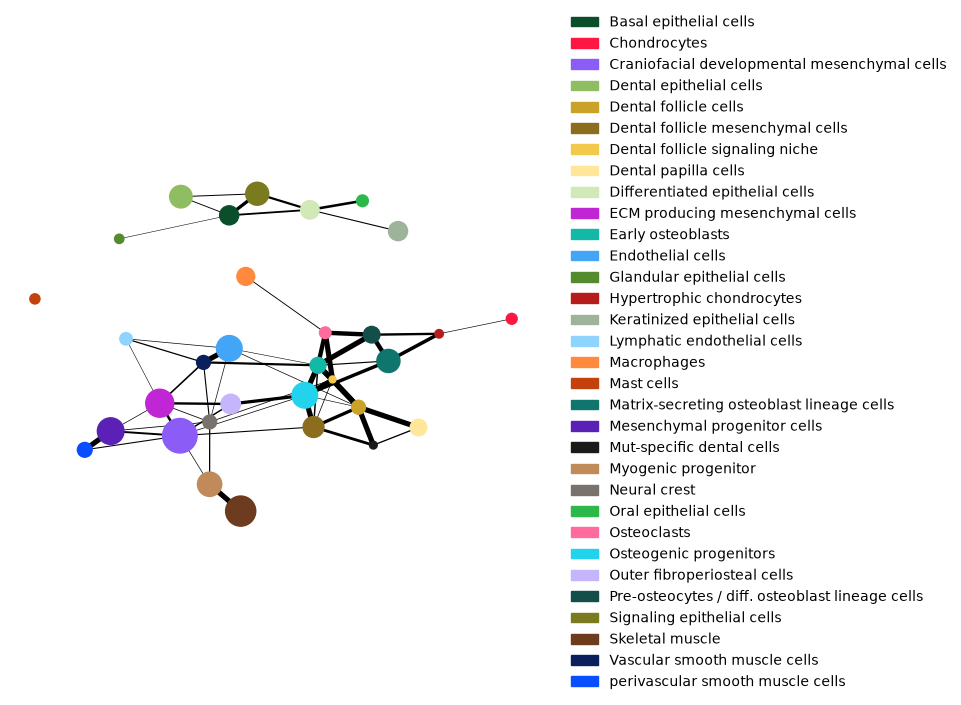

In [11]:
sc.tl.paga(adata, groups="annotation", neighbors_key="neighbors_diffmap")
cats = adata.obs[adata.uns["paga"]["groups"]].cat.categories
n_groups = len(adata.obs[adata.uns["paga"]["groups"]].cat.categories)
adata.uns["annotation_colors"] = [u.L2_COLORS.get(c, "#CCCCCC") for c in cats]

ax = sc.pl.paga(adata, color="annotation", threshold=0.1, frameon=False,
                edge_width_scale=0.5, node_size_scale=1.2, node_size_power=0.8,
                labels=[""] * n_groups, show=False)

ax.legend(handles=[Patch(color=u.L2_COLORS.get(c, "#CCCCCC"), label=c) for c in cats],
          loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.show()

In [45]:
os.makedirs(d.paga_dir, exist_ok=True)
adata.write_h5ad(d.paga_dir / "adata.h5ad")
print("Wrote", d.paga_dir / "adata.h5ad")

Wrote C:\Users\sevco\Documents\phd\proj_2026_Zimcik_Xenium\Xenium_Analysis_SATB2_UMG_2026\data\04_PAGA\adata.h5ad


# Subcluster - vyber anotovanych clusterov

TODO:
Vyhadzujeme
- Mast cells
- Perivascular smooth muscle cells
- Vascular smooth muscle cells
- Endothelial cells
- Glandular epithelial cells
- Myogenic progenitor
- Mesenchymal progenitor cells
- Oral epithelial cells

In [12]:
exclude = [
    "Mast cells",
    "Skeletal muscle",
    "perivascular smooth muscle cells",
    "Vascular smooth muscle cells",
    "Endothelial cells",
    "Glandular epithelial cells",
    "Myogenic progenitor",
    "Mesenchymal progenitor cells",
    "Oral epithelial cells",
    "Keratinized epithelial cells",
    "Lymphatic endothelial cells",
    "Signaling epithelial cells",
    "Craniofacial developmental mesenchymal cells",
    "ECM producing mesenchymal cells",

]

# catch typos: names in the list that don't exist in the data
missing = set(exclude) - set(adata.obs["annotation"].cat.categories)
if missing:
    print("Not found in annotation:", missing)

adata_sub = adata[~adata.obs["annotation"].isin(exclude)].copy()

# drop the now-empty categories and realign colors
adata_sub.obs["annotation"] = adata_sub.obs["annotation"].cat.remove_unused_categories()
adata_sub.uns["annotation_colors"] = [
    u.L2_COLORS.get(c, "#CCCCCC") for c in adata_sub.obs["annotation"].cat.categories
]

print(adata.n_obs, "->", adata_sub.n_obs)
print(adata_sub.obs["annotation"].value_counts())

200725 -> 80722
annotation
Osteogenic progenitors                             11960
Matrix-secreting osteoblast lineage cells           9265
Dental epithelial cells                             8663
Dental follicle mesenchymal cells                   7197
Outer fibroperiosteal cells                         6070
Basal epithelial cells                              5730
Differentiated epithelial cells                     5324
Macrophages                                         4840
Pre-osteocytes / diff. osteoblast lineage cells     4012
Dental papilla cells                                4005
Early osteoblasts                                   3623
Dental follicle cells                               2617
Neural crest                                        2528
Osteoclasts                                         1649
Chondrocytes                                        1415
Hypertrophic chondrocytes                            762
Mut-specific dental cells                            601
Dent

Tym ze sme si vybrali len dane clustery, tak si musime vypocitat PCA, neighbors a UMAP nanovo, pretoze sa zmeni globalna struktura dat.

In [13]:
# graph for the subset: PCA -> kNN -> diffusion map -> kNN on diffusion components
sc.pp.pca(adata_sub, n_comps=50, random_state=42)
sc.pp.neighbors(adata_sub, n_neighbors=25, use_rep="X_pca", random_state=42)
sc.tl.diffmap(adata_sub, n_comps=15)

# DC0 is the trivial eigenvector -> leave it out of the graph, but keep X_diffmap intact for sc.tl.dpt
adata_sub.obsm["X_diffmap_nt"] = adata_sub.obsm["X_diffmap"][:, 1:]
sc.pp.neighbors(adata_sub, n_neighbors=25, use_rep="X_diffmap_nt",
                key_added="neighbors_diffmap", random_state=42)

In [14]:
MIRROR = ["mut_2", "wt_3", "wt_4"]   # samples to mirror left-right
TRANSFORMS = {s: {"flip": "x"} for s in MIRROR}
# per-sample control, e.g.:
# TRANSFORMS = {"mut_2": {"flip": "x"}, "wt_3": {"flip": "y"}, "wt_4": {"flip": "x", "rotate": 90}}

f.orient_samples(adata_sub, TRANSFORMS)

AnnData object with n_obs × n_vars = 80722 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'region', 'sample', 'condition', 'n_genes', 'leiden_0.5', 'leiden_1.0', 'leiden_1.5', 'leiden_2.0', 'score_craniofacial_developmental_mesenchyme', 'score_osteogenic_progenitors', 'score_myogenic_progenitors', 'score_differentiated_skeletal_muscle_cells', 'score_ECM_producing_mesenchymal_cells', 'score_mesenchymal_progenitors', 'score_basal_epithelial_cells', 'score_endothelial_cells', 'score_differentiated_osteoblast_lineage_cells', 'score_keratinized_epithelial_cells', 'score_early_odontogenic_mesenchyme', 'score_dental_epithelial_cells', 'score_matrix_remodeling_osteogenic_cells', 'score_SATB2_positive_signaling_mesenchymal_cells', 'score_signaling_epithelial_cells', 'score_tendon_ligament_like_mesenchymal_cells', 'score_macrophages', 'score_mature_osteoblast_lineage_cells', 'score_differentiated_epithelial_ce

In [ ]:
os.makedirs(d.paga_dir, exist_ok=True)
adata_sub.write_h5ad(d.paga_dir / "adata_sub.h5ad")
print("Wrote", d.paga_dir / "adata_sub.h5ad")

Wrote C:\Users\sevco\Documents\phd\proj_2026_Zimcik_Xenium\Xenium_Analysis_SATB2_UMG_2026\data\04_PAGA\adata.h5ad


# CHECKPOINT
**ak chceme vizualizovat, staci si nahrat adata odtialto**

In [ ]:
adata_sub = sc.read_h5ad(d.paga_dir / "adata_sub.h5ad")

## Taktika: 
- ak nechame len anotovane clustre, tak PAGA nezachytava vyssiu strukturu dat inak ako UMAP.
- aby sme vyuzili PAGA lepsie, vytvorime si subclustre v clustroch ktore nas zaujimaju. Tymto sa nam moze podarit zachytit aj vyssiu strukturu dat, pretoze subclustre budu mat vacsiu granularitu a PAGA bude mat viac hran.

Parametre:
- `SUB_RES` - leiden resolution inside each annotation, cim vyssia hodnota, tym viac subclusterov
- `MIN_CELLS` - ak je pocet celkovych buniek v anotovanych clusteroch mensia ako tato hodnota, tak sa subclusterovanie neaplikuje
- `MIN_SUB` - ak je pocet buniek v subclustri mensi ako tato hodnota, tak sa subcluster priradi k najblizsiemu subclustru

In [18]:
# subcluster every annotation separately (leiden restricted to the cells of one annotation)
SUB_RES = 0.05      # leiden resolution inside each annotation
MIN_CELLS = 400    # smaller annotations stay as one subcluster
MIN_SUB = 100       # smaller subclusters (cells isolated inside the restricted graph) get merged back

adata_sub.obs["annotation_sub"] = adata_sub.obs["annotation"].astype(str) + ",0"
for ann in adata_sub.obs["annotation"].cat.categories:
    mask = (adata_sub.obs["annotation"] == ann).values
    if mask.sum() < MIN_CELLS:
        continue
    sc.tl.leiden(adata_sub, resolution=SUB_RES, restrict_to=("annotation", [ann]),
                 neighbors_key="neighbors_diffmap", key_added="_tmp", random_state=42)
    adata_sub.obs.loc[mask, "annotation_sub"] = adata_sub.obs.loc[mask, "_tmp"].astype(str)
adata_sub.obs.drop(columns="_tmp", inplace=True)
adata_sub.uns.pop("_tmp", None)

# merge tiny subclusters: each cell goes to the most connected large subcluster of the same annotation
conn = adata_sub.obsp["neighbors_diffmap_connectivities"].tocsr()
labels = adata_sub.obs["annotation_sub"].to_numpy(dtype=object)
ann_arr = adata_sub.obs["annotation"].to_numpy(dtype=object)
sizes = pd.Series(labels).value_counts()
is_tiny = pd.Series(labels).isin(sizes.index[sizes < MIN_SUB]).to_numpy()
largest = pd.Series(labels[~is_tiny]).groupby(ann_arr[~is_tiny]).agg(lambda s: s.value_counts().index[0])
new = labels.copy()
for i in np.flatnonzero(is_tiny):
    nb, w = conn.indices[conn.indptr[i]:conn.indptr[i + 1]], conn.data[conn.indptr[i]:conn.indptr[i + 1]]
    ok = ~is_tiny[nb] & (ann_arr[nb] == ann_arr[i])
    new[i] = pd.Series(w[ok]).groupby(labels[nb][ok]).sum().idxmax() if ok.any() else largest[ann_arr[i]]
adata_sub.obs["annotation_sub"] = new
print(f"merged {is_tiny.sum()} cells from {(sizes < MIN_SUB).sum()} tiny subclusters")

# short numeric ids ("0", "1", ...) ordered by parent annotation -> used as PAGA nodes and ROOT
lookup = (adata_sub.obs.groupby(["annotation", "annotation_sub"], observed=True)
          .size().rename("n_cells").reset_index())
lookup["_k"] = lookup["annotation_sub"].str.rsplit(",", n=1).str[-1].astype(int)
lookup = lookup.sort_values(["annotation", "_k"]).drop(columns="_k").reset_index(drop=True)
lookup["subcluster"] = lookup.index.astype(str)
adata_sub.obs["subcluster"] = pd.Categorical(
    adata_sub.obs["annotation_sub"].map(dict(zip(lookup["annotation_sub"], lookup["subcluster"]))),
    categories=lookup["subcluster"],
)
# colours: each annotation's base colour fading towards grey across its subclusters (subcluster 0 = base colour)
from matplotlib.colors import to_rgb, to_hex

def shades(base, n, grey="#bdbdbd", max_mix=0.75):
    b, g = np.array(to_rgb(base)), np.array(to_rgb(grey))
    return [to_hex((1 - t) * b + t * g) for t in np.linspace(0, max_mix if n > 1 else 0, n)]

sub_colors = {}
for ann, grp in lookup.groupby("annotation", observed=True, sort=False):
    sub_colors.update(zip(grp["subcluster"], shades(u.L2_COLORS.get(ann, "#CCCCCC"), len(grp))))
lookup["color"] = lookup["subcluster"].map(sub_colors)
adata_sub.uns["subcluster_colors"] = [sub_colors[s] for s in adata_sub.obs["subcluster"].cat.categories]
adata_sub.uns["annotation_colors"] = [u.L2_COLORS.get(c, "#CCCCCC") for c in adata_sub.obs["annotation"].cat.categories]

print(lookup[["subcluster", "annotation", "annotation_sub", "n_cells"]].to_string(index=False))

merged 800 cells from 324 tiny subclusters
subcluster                                      annotation                                    annotation_sub  n_cells
         0                          Basal epithelial cells                          Basal epithelial cells,0     3710
         1                          Basal epithelial cells                          Basal epithelial cells,1     2020
         2                                    Chondrocytes                                    Chondrocytes,0      332
         3                                    Chondrocytes                                    Chondrocytes,1      303
         4                                    Chondrocytes                                    Chondrocytes,2      291
         5                                    Chondrocytes                                    Chondrocytes,3      280
         6                                    Chondrocytes                                    Chondrocytes,4      209
         7   

Parameter:
- `THRESHOLD` - threshold for filtering edges in the PAGA graph, cim vyssia hodnota, tym menej hran v grafe

In [19]:
THRESHOLD = 0.4

# outline subclusters dominated by one condition
DIFF_WT_vs_MUT = True
DIFF_THRESHOLD = 0.95                      # fraction of cells from one condition needed for an outline
COND_COLORS = {"wt": "#7C3AED", "mut": "#ED8936"}


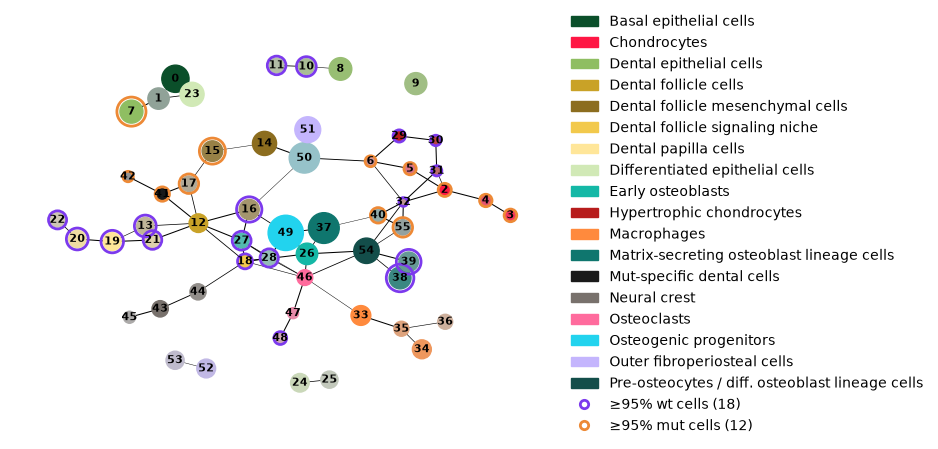

In [20]:
sc.tl.paga(adata_sub, groups="subcluster", neighbors_key="neighbors_diffmap")
cats = adata_sub.obs["annotation"].cat.categories

# nodes = subclusters (labelled by id), colour = shade of the parent annotation colour
ax = sc.pl.paga(adata_sub, color="subcluster", threshold=THRESHOLD, frameon=False,
                edge_width_scale=0.1, node_size_scale=1.2, node_size_power=0.8,
                fontsize=8, show=False)

handles = [Patch(color=u.L2_COLORS.get(c, "#ACACAC"), label=c) for c in cats]

if DIFF_WT_vs_MUT:
    groups = adata_sub.obs["subcluster"].cat.categories
    frac = (pd.crosstab(adata_sub.obs["subcluster"], adata_sub.obs["condition"], normalize="index")
            .reindex(index=groups, columns=list(COND_COLORS), fill_value=0))
    # the node scatter drawn by sc.pl.paga: one point per subcluster, in category order
    nodes = next(c for c in ax.collections if len(c.get_offsets()) == len(groups) and len(c.get_sizes()))
    pos, sizes = nodes.get_offsets(), nodes.get_sizes()
    sizes = np.broadcast_to(sizes, len(groups))
    for cond, col in COND_COLORS.items():
        hit = (frac[cond] >= DIFF_THRESHOLD).to_numpy()
        ax.scatter(pos[hit, 0], pos[hit, 1], s=sizes[hit] * 1.6, facecolors="none",
                   edgecolors=col, linewidths=2, zorder=nodes.get_zorder() + 1)
        handles.append(plt.Line2D([], [], marker="o", ls="", mfc="none", mec=col, mew=2,
                                  label=f"≥{DIFF_THRESHOLD:.0%} {cond} cells ({hit.sum()})"))

ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.show()

In [21]:
print(frac.round(2).to_string())

condition     wt   mut
subcluster            
0           0.65  0.35
1           0.51  0.49
2           0.00  1.00
3           0.00  1.00
4           0.00  1.00
5           0.00  1.00
6           0.01  0.99
7           0.03  0.97
8           0.81  0.19
9           0.89  0.11
10          1.00  0.00
11          1.00  0.00
12          0.95  0.05
13          1.00  0.00
14          0.08  0.92
15          0.01  0.99
16          0.98  0.02
17          0.00  1.00
18          1.00  0.00
19          1.00  0.00
20          1.00  0.00
21          1.00  0.00
22          1.00  0.00
23          0.49  0.51
24          0.52  0.48
25          0.50  0.50
26          0.91  0.09
27          1.00  0.00
28          0.98  0.02
29          1.00  0.00
30          1.00  0.00
31          1.00  0.00
32          0.98  0.02
33          0.45  0.55
34          0.46  0.54
35          0.47  0.53
36          0.47  0.53
37          0.39  0.61
38          0.97  0.03
39          1.00  0.00
40          0.05  0.95
41         

In [22]:
# ---------------- parameters ----------------
BAR_ADATA = adata_sub
CLUSTER_KEY = "subcluster"                 # e.g. "annotation", "subcluster", "annotation_cluster"
COND_KEY = "condition"
CONDS = ["wt", "mut"]                      # stacking order (bottom -> top)
BAR_COLORS = {"wt": "#7C3AED", "mut": "#ED8936"}
BAR_LABELS = {"wt": r"$\it{Satb2}^{wt}$", "mut": r"$\it{Satb2}^{mut}$"}
NORMALIZE_BY_CONDITION = True              # correct for different total cell numbers per condition
SHOW_DIFF_THRESHOLD = True                 # dotted lines at DIFF_THRESHOLD / 1 - DIFF_THRESHOLD
LABEL_WITH_ANNOTATION = True               # subcluster ticks as "id  annotation"
MIN_CELLS_BAR = 0                          # hide clusters with fewer cells
FIGSIZE = (14, 4.5)


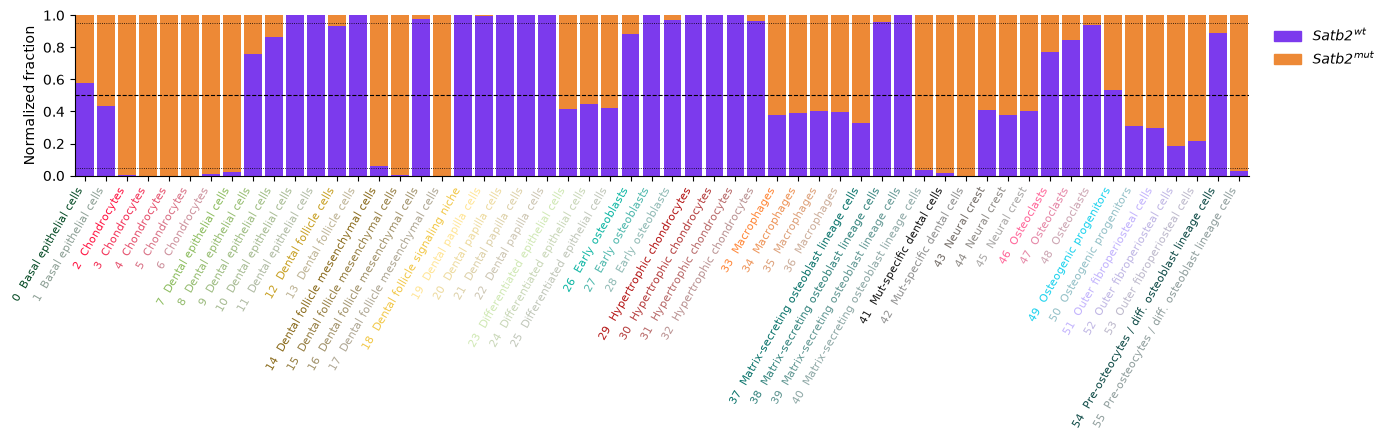

In [23]:
# ---------------- plot ----------------
obs = BAR_ADATA.obs
ct = pd.crosstab(obs[CLUSTER_KEY], obs[COND_KEY]).reindex(columns=CONDS, fill_value=0)
ct = ct[ct.sum(axis=1) >= MIN_CELLS_BAR]

# order: categorical order for subclusters (already grouped by annotation), palette order for cell types
if CLUSTER_KEY == "subcluster" or not set(ct.index) & set(u.L2_COLORS):
    order = [c for c in obs[CLUSTER_KEY].cat.categories if c in ct.index]
else:
    order = [t for t in u.L2_COLORS if t in ct.index] + [t for t in ct.index if t not in u.L2_COLORS]
ct = ct.loc[order]

# normalize to total cells per condition, then to 1 within each cluster
norm = ct.div(ct.sum(axis=0), axis=1) if NORMALIZE_BY_CONDITION else ct
norm = norm.div(norm.sum(axis=1), axis=0)

# tick colours: <key>_colors from the AnnData, otherwise the L2 palette
key_colors = dict(zip(obs[CLUSTER_KEY].cat.categories, BAR_ADATA.uns.get(f"{CLUSTER_KEY}_colors", [])))
tick_colors = [key_colors.get(c, u.L2_COLORS.get(c, "k")) for c in norm.index]
if CLUSTER_KEY == "subcluster" and LABEL_WITH_ANNOTATION:
    ann_of = obs.groupby("subcluster", observed=True)["annotation"].first()
    tick_labels = [f"{c}  {ann_of[c]}" for c in norm.index]
else:
    tick_labels = [str(t).replace("_", " ") for t in norm.index]

fig, ax = plt.subplots(figsize=FIGSIZE)
norm.plot(kind="bar", stacked=True, ax=ax, width=0.85, color=[BAR_COLORS[c] for c in CONDS], legend=False)

ax.axhline(0.5, color="black", lw=0.8, ls="--")
if SHOW_DIFF_THRESHOLD and "DIFF_THRESHOLD" in globals():
    for y in (DIFF_THRESHOLD, 1 - DIFF_THRESHOLD):
        ax.axhline(y, color="black", lw=0.6, ls=":")
ax.set_ylim(0, 1)
ax.set_xlim(-0.5, len(norm) - 0.5)
ax.set_ylabel("Normalized fraction" if NORMALIZE_BY_CONDITION else "Fraction")
ax.set_xlabel("")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=BAR_COLORS[c]) for c in CONDS]
ax.legend(handles, [BAR_LABELS.get(c, c) for c in CONDS], frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xticks(range(len(norm)))
ax.set_xticklabels(tick_labels, rotation=60, ha="right", fontsize=8)
for lab, col in zip(ax.get_xticklabels(), tick_colors):
    lab.set_color(col)
fig.tight_layout()
plt.show()

### Kod na otazky:
- ake su markery pre vybrany subcluster?
- ako vybrany subcluster je localizovany v tkanive? (PAGA, UMAP, spatial)

In [24]:
key = "subcluster"      # na akom clusteringu pracujeme
keep = ["54", "55"]     # ktore subclustre highlightnut (aj viac, napr. ["41", "42"])
ADATA = adata_sub
SAMPLE = ["wt_1", "wt_2","wt_3", "wt_4", "mut_1", "mut_2","mut_3", "mut_4"]      # ktore samples zobrazit (aj viac, napr. ["wt_1", "mut_3"])
POINT_SIZE = 30
FIGSIZE = (5, 9)        # per sample 
EMBEDDING = "spatial"   # "X_umap" alebo "spatial"
NCOLS = 4

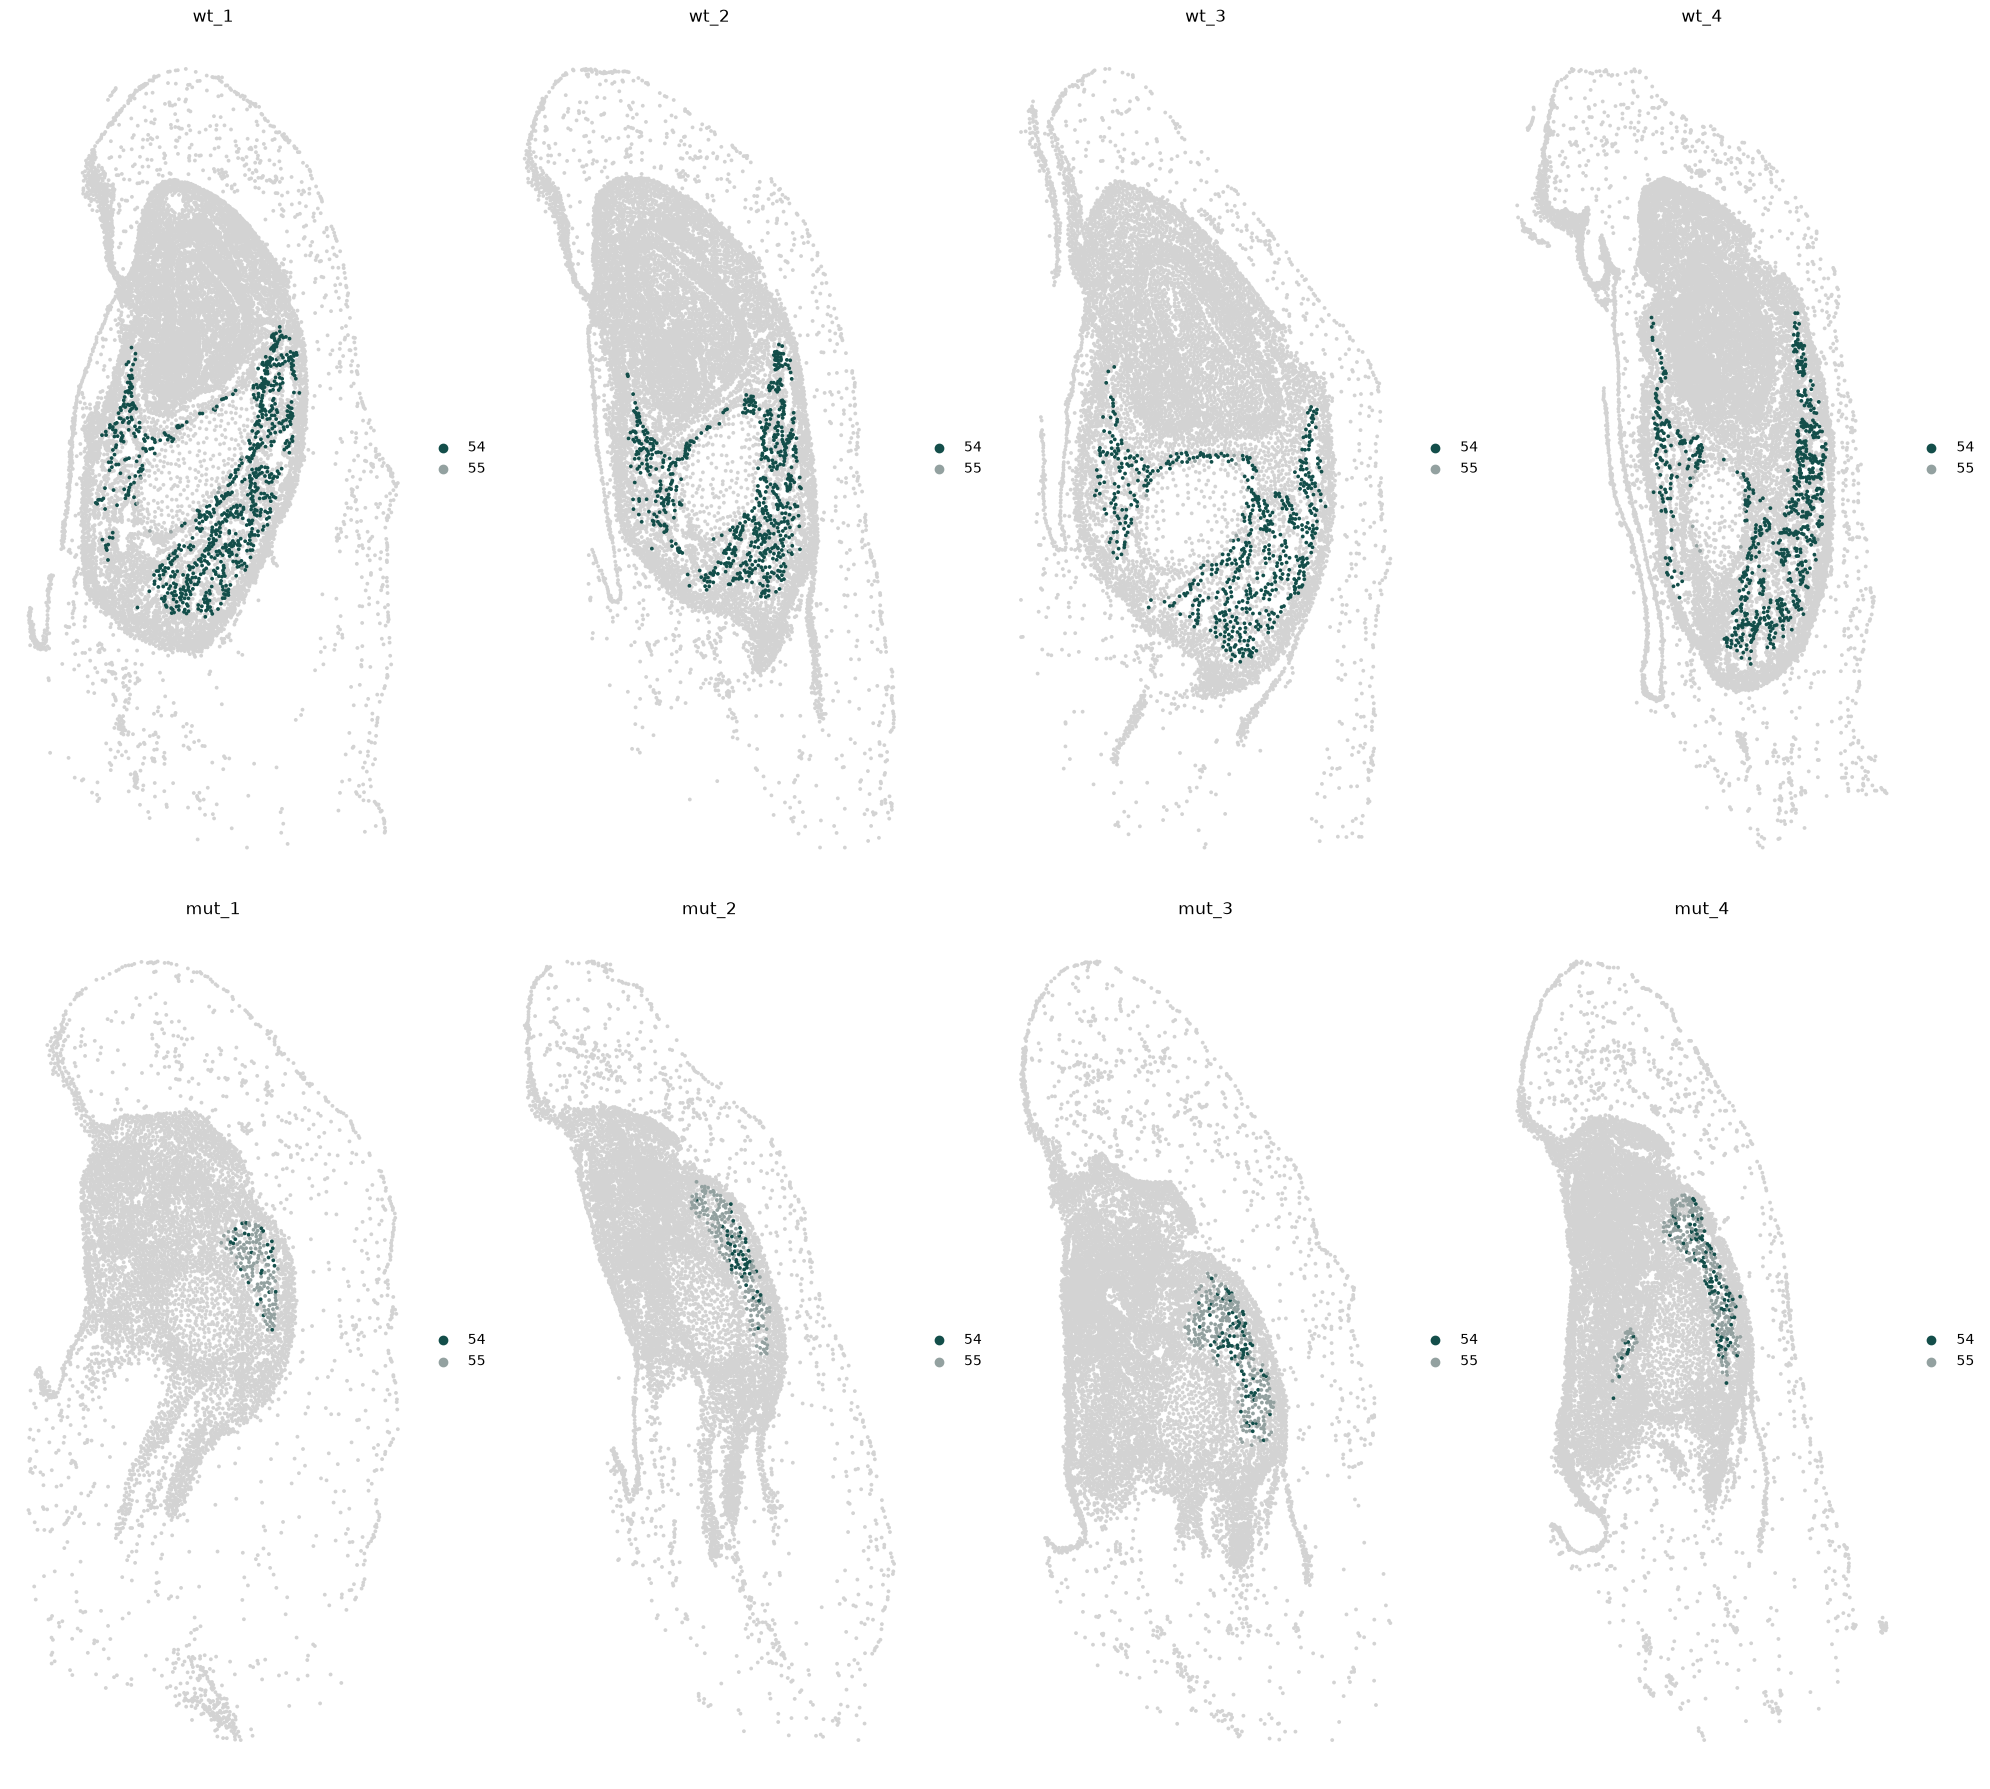

In [25]:
# colours of the chosen clusters, taken from <key>_colors
cats = list(ADATA.obs[key].cat.categories)
key_colors = dict(zip(cats, ADATA.uns[f"{key}_colors"]))
keep = [str(k) for k in keep]
missing = set(keep) - set(cats)
assert not missing, f"not in {key}: {missing}"

col = ADATA.obs[key].astype(str).where(ADATA.obs[key].astype(str).isin(keep))
ADATA.obs["highlight"] = pd.Categorical(col, categories=keep)
ADATA.uns["highlight_colors"] = [key_colors[k] for k in keep]

ncols = min(NCOLS, len(SAMPLE))
nrows = int(np.ceil(len(SAMPLE) / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(FIGSIZE[0] * ncols, FIGSIZE[1] * nrows), squeeze=False)
for ax, smp in zip(axs.flat, SAMPLE):
    sub = ADATA[ADATA.obs["sample"] == smp]
    sub = sub[np.argsort(sub.obs["highlight"].notna().to_numpy(), kind="stable")]   # highlighted cells on top
    sc.pl.embedding(sub, basis=EMBEDDING, color="highlight", size=POINT_SIZE, na_color="lightgrey",
                    na_in_legend=False, frameon=False, title=smp, ax=ax, show=False)
for ax in axs.flat[len(SAMPLE):]:
    ax.set_axis_off()
plt.tight_layout()
plt.show()

### Markery subclustrov (rank_genes_groups)
- kazdy cluster vs **vsetky ostatne bunky** (wilcoxon na `lognorm`), pocita sa raz pre vsetky clustre
- `MARKER_GROUPS` len vyberie, ktore clustre sa zobrazia

In [26]:
# ---------------- markers: parameters ----------------
MARKER_ADATA = adata_sub
MARKER_KEY = "subcluster"                  # clustering column, e.g. "subcluster" or "annotation"
MARKER_GROUPS = ["45", "52", "55"]         # clusters to plot; None = all
N_GENES = 20                               # genes per rank plot
MARKER_LAYER = "lognorm"                   # log-normalised expression (X is scaled -> not for DE)
MARKER_METHOD = "wilcoxon"
NCOLS_MARKERS = 4                          # rank plots per row
SHAREY = False                             # same y-axis (score) for all panels
SHOW_DOTPLOT = True                        # dotplot of the top N_DOT markers per cluster
N_DOT = 5

In [27]:
# ---------------- markers: compute (each cluster vs all other cells) ----------------
MARKER_UNS = f"markers_{MARKER_KEY}"
params = {"groupby": MARKER_KEY, "layer": MARKER_LAYER, "method": MARKER_METHOD,
          "n_cells": MARKER_ADATA.n_obs, "n_groups": MARKER_ADATA.obs[MARKER_KEY].nunique()}
if MARKER_ADATA.uns.get(MARKER_UNS, {}).get("_setup") != params:   # recompute only when the setup changed
    sc.tl.rank_genes_groups(MARKER_ADATA, MARKER_KEY, method=MARKER_METHOD, layer=MARKER_LAYER,
                            use_raw=False, key_added=MARKER_UNS)
    MARKER_ADATA.uns[MARKER_UNS]["_setup"] = params

marker_groups = [str(g) for g in (MARKER_GROUPS or MARKER_ADATA.obs[MARKER_KEY].cat.categories)]
missing = set(marker_groups) - set(MARKER_ADATA.obs[MARKER_KEY].astype(str))
assert not missing, f"not in {MARKER_KEY}: {missing}"

top_markers = pd.DataFrame({g: sc.get.rank_genes_groups_df(MARKER_ADATA, group=g, key=MARKER_UNS)["names"]
                            .head(N_GENES).to_numpy() for g in marker_groups})
top_markers.index = np.arange(1, N_GENES + 1)
top_markers

c:\Users\sevco\Documents\diplomka\DiplomaThesis\venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
c:\Users\sevco\Documents\diplomka\DiplomaThesis\venv\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
c:\Users\sevco\Documents\diplomka\DiplomaThesis\venv\Lib\site-packages\scanpy\tools\_rank_genes_g

,45,52,55
1,Mcam,Scx,Dmp1
2,Sorbs1,Thbs4,Enpp1
3,Sox10,Postn,Col1a2
4,Col18a1,Fn1,Col1a1
5,Dst,Meox1,Ank
6,Lama4,Gas1,Fam20c
7,Afap1l2,Col1a2,Timp1
8,Tgfbr3,Fmod,Ibsp
9,Ngfr,Col1a1,Mmp13
10,Hspg2,Thbs1,Lox


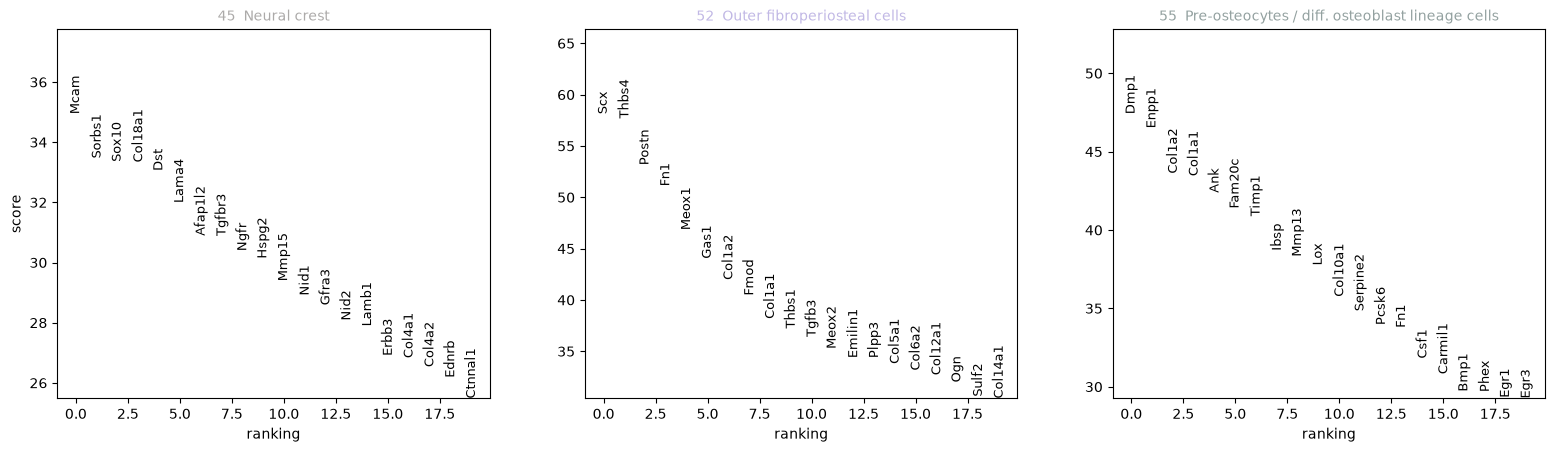

categories: 0, 1, 2, etc.
var_group_labels: 45, 52, 55


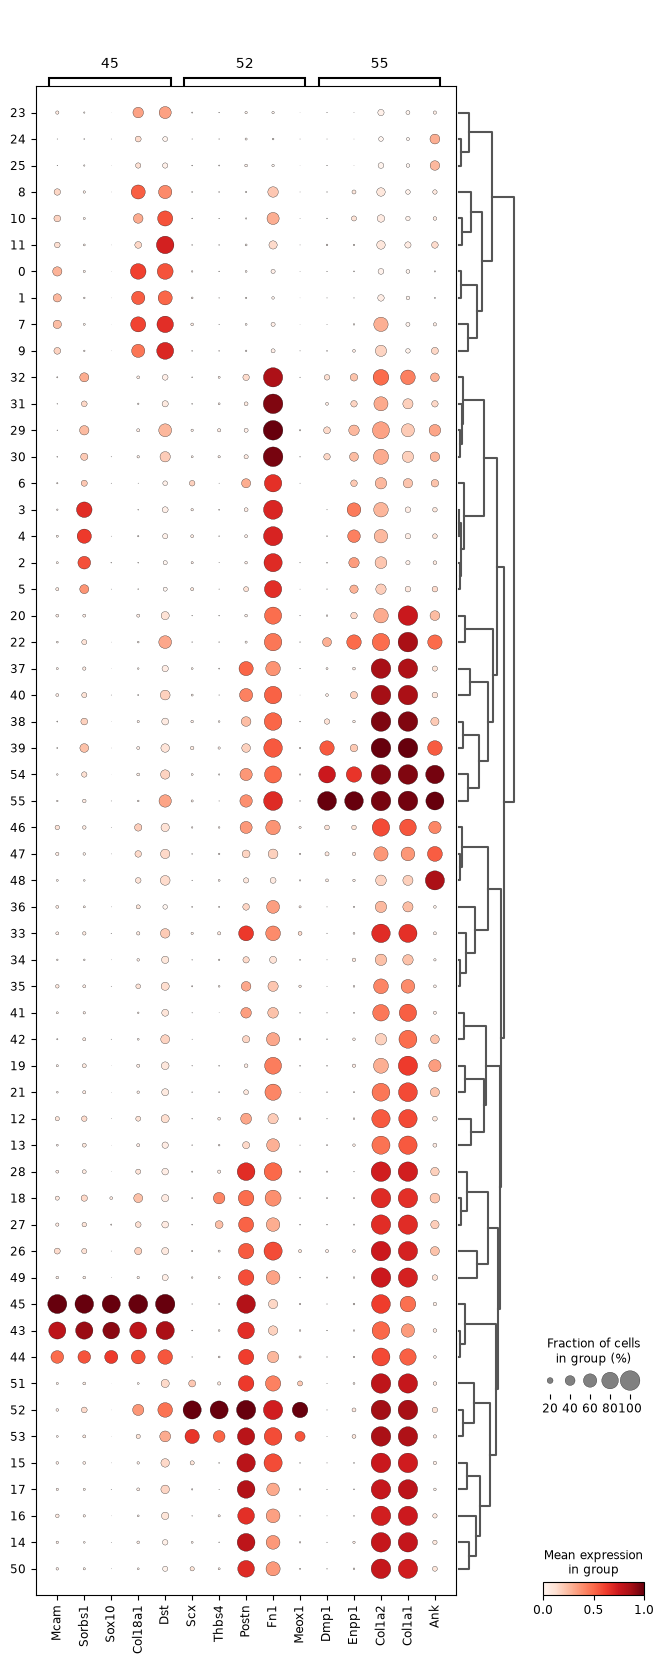

In [28]:
# ---------------- markers: rank plots ----------------
sc.pl.rank_genes_groups(MARKER_ADATA, groups=marker_groups, key=MARKER_UNS, n_genes=N_GENES,
                        ncols=NCOLS_MARKERS, sharey=SHAREY, fontsize=9, show=False)
fig = plt.gcf()
key_colors = dict(zip(MARKER_ADATA.obs[MARKER_KEY].cat.categories, MARKER_ADATA.uns.get(f"{MARKER_KEY}_colors", [])))
ann_of = (MARKER_ADATA.obs.groupby(MARKER_KEY, observed=True)["annotation"].first()
          if MARKER_KEY != "annotation" else None)
for ax, g in zip(fig.axes, marker_groups):
    ax.set_title(f"{g}  {ann_of[g]}" if ann_of is not None else g, color=key_colors.get(g, "k"), fontsize=10)
plt.show()

if SHOW_DOTPLOT:
    sc.pl.rank_genes_groups_dotplot(MARKER_ADATA, groups=marker_groups, key=MARKER_UNS, n_genes=N_DOT,
                                    layer=MARKER_LAYER, use_raw=False, standard_scale="var")

TODO: 
- Express subcluster vs rest
- Express subcluster vs subcluster
- Vizualizace
  - volcano plots (FDR, log2FC)

In [29]:
# ---------------- differential expression: parameters ----------------
DE_ADATA = adata_sub
DE_KEY = "subcluster"                      # clustering column
SUBCLUSTER_TO_COMPARE = ["54","55"]
COMPARE_TO = "each_other"                  # "each_other": each vs the other selected ones
                                           # "all":        each vs all other cells
                                           # "49":         each vs one reference subcluster
LOG2FC = 1.0                               # min |log2 fold change|
PVAL = 0.05                                # max BH-adjusted p-value
DIRECTION = "both"                           # "up" | "down" | "both"
MIN_PCT = 0.10                             # gene detected in >= this fraction of cells (group for up, reference for down)
LAYER = "lognorm"                          # log-normalised expression (X is scaled -> not for DE)
METHOD = "wilcoxon"
TOP_N = 10                                 # genes per group in the dotplot / labelled in volcanos
NCOLS_DE = 3                               # volcano panels per row

In [30]:
# ---------------- differential expression: run ----------------
de_groups = [str(g) for g in SUBCLUSTER_TO_COMPARE]
lab = DE_ADATA.obs[DE_KEY].astype(str)
missing = set(de_groups) - set(lab)
assert not missing, f"not in {DE_KEY}: {missing}"

if COMPARE_TO == "each_other":
    assert len(de_groups) >= 2, 'COMPARE_TO="each_other" needs >= 2 subclusters (use "all" for one)'
    de_lab, reference = lab.where(lab.isin(de_groups)), "rest"
elif COMPARE_TO == "all":
    de_lab, reference = lab.where(lab.isin(de_groups), "other"), "other"
else:
    reference = str(COMPARE_TO)
    assert reference in set(lab) and reference not in de_groups, f"bad reference {reference!r}"
    de_lab = lab.where(lab.isin(de_groups + [reference]))

m = de_lab.notna().to_numpy()
cats = de_groups + ([reference] if reference != "rest" else [])
de = sc.AnnData(X=DE_ADATA[m].layers[LAYER], obs=pd.DataFrame({"group": pd.Categorical(de_lab[m], categories=cats)},
                index=DE_ADATA.obs_names[m]), var=pd.DataFrame(index=DE_ADATA.var_names))
key_colors = dict(zip(DE_ADATA.obs[DE_KEY].cat.categories, DE_ADATA.uns.get(f"{DE_KEY}_colors", [])))
de.uns["group_colors"] = [key_colors.get(c, "#bdbdbd") for c in cats]
print(de.obs["group"].value_counts().to_string())

sc.tl.rank_genes_groups(de, "group", groups=de_groups, reference=reference, method=METHOD, use_raw=False)

# fraction of cells expressing each gene (group / reference), computed here for every COMPARE_TO mode
detected = de.X > 0
grp = de.obs["group"].astype(str).to_numpy()
def pct(mask):
    return pd.Series(np.asarray(detected[mask].mean(axis=0)).ravel(), index=de.var_names)

def de_table(g):
    df = sc.get.rank_genes_groups_df(de, group=g)
    ref_mask = (grp != g) if reference == "rest" else (grp == reference)
    df["pct_group"] = df["names"].map(pct(grp == g)).to_numpy()
    df["pct_ref"] = df["names"].map(pct(ref_mask)).to_numpy()
    up = (df["logfoldchanges"] >= LOG2FC) & (df["pct_group"] >= MIN_PCT)
    down = (df["logfoldchanges"] <= -LOG2FC) & (df["pct_ref"] >= MIN_PCT)
    sel = {"up": up, "down": down, "both": up | down}[DIRECTION]
    df["significant"] = sel & (df["pvals_adj"] < PVAL)
    df.insert(0, "group", g)
    return df

DE_ALL = {g: de_table(g) for g in de_groups}
# ranked by the test score: log2FC is inflated (~30) for genes not detected in the reference
DE_SIG = {g: df[df["significant"]].sort_values("scores", key=abs, ascending=False) for g, df in DE_ALL.items()}
ref_name = {"rest": "other selected", "other": "all other cells"}.get(reference, reference)
for g, df in DE_SIG.items():
    print(f"{DE_KEY} {g} vs {ref_name}: {len(df)} genes ({DIRECTION}, |log2FC| >= {LOG2FC}, padj < {PVAL})")
pd.concat(DE_SIG.values())[["group", "names", "scores", "logfoldchanges", "pvals_adj", "pct_group", "pct_ref"]].round(4)

group
54    3112
55     900
subcluster 54 vs other selected: 200 genes (both, |log2FC| >= 1.0, padj < 0.05)
subcluster 55 vs other selected: 200 genes (both, |log2FC| >= 1.0, padj < 0.05)


,group,names,scores,logfoldchanges,pvals_adj,pct_group,pct_ref
1999,54,Col10a1,-31.745701,-7.2578,0.0000,0.0312,0.7144
1998,54,Pcsk6,-24.813700,-2.6943,0.0000,0.4152,0.8267
0,54,Gja1,23.992901,2.0638,0.0000,0.8567,0.6033
1997,54,Enpp1,-23.128300,-2.0627,0.0000,0.7246,0.9333
1996,54,Cspg4,-22.372999,-3.0479,0.0000,0.2076,0.6378
...,...,...,...,...,...,...,...
172,55,Jam2,3.049400,1.0574,0.0147,0.1378,0.0704
1860,55,Cemip,-3.041700,-1.1672,0.0150,0.0611,0.1272
176,55,Rgcc,2.963700,1.1354,0.0188,0.1322,0.0688
180,55,Slc2a1,2.798700,1.4826,0.0307,0.1033,0.0431


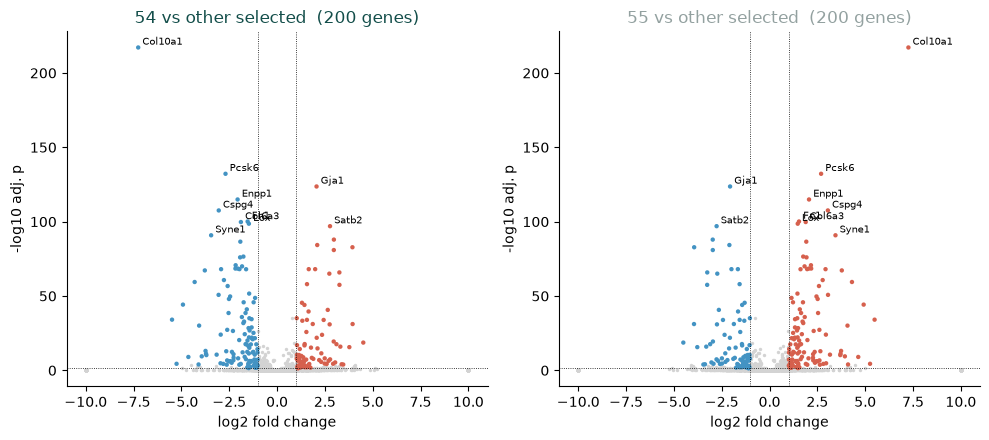

In [31]:
# ---------------- volcano plots ----------------
n = len(de_groups); ncols = min(NCOLS_DE, n); nrows = int(np.ceil(n / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)
for ax, g in zip(axs.flat, de_groups):
    df = DE_ALL[g]
    x = df["logfoldchanges"].clip(-10, 10)     # capped: genes absent in one side reach ~ +-30
    y = -np.log10(df["pvals_adj"].clip(lower=1e-300))
    sig = df["significant"].to_numpy()
    ax.scatter(x[~sig], y[~sig], s=6, c="lightgrey", lw=0)
    ax.scatter(x[sig], y[sig], s=10, c=np.where(x[sig] > 0, "#d6604d", "#4393c3"), lw=0)
    for v in (-LOG2FC, LOG2FC):
        ax.axvline(v, color="black", lw=0.6, ls=":")
    ax.axhline(-np.log10(PVAL), color="black", lw=0.6, ls=":")
    for _, r in DE_SIG[g].head(TOP_N).iterrows():
        ax.annotate(r["names"], (np.clip(r["logfoldchanges"], -10, 10), -np.log10(max(r["pvals_adj"], 1e-300))),
                    fontsize=7, xytext=(3, 2), textcoords="offset points")
    ax.set_title(f"{g} vs {ref_name}  ({sig.sum()} genes)", color=key_colors.get(g, "k"))
    ax.set_xlabel("log2 fold change"); ax.set_ylabel("-log10 adj. p")
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
for ax in axs.flat[n:]:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

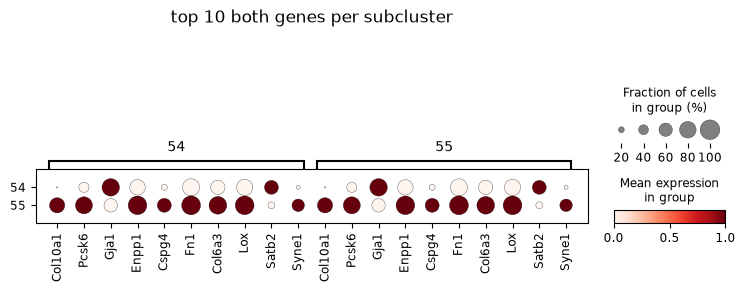

In [32]:
# ---------------- dotplot of the top genes ----------------
markers = {g: DE_SIG[g]["names"].head(TOP_N).tolist() for g in de_groups if len(DE_SIG[g])}
if markers:
    sc.pl.dotplot(de, markers, groupby="group", standard_scale="var", use_raw=False,
                  title=f"top {TOP_N} {DIRECTION} genes per {DE_KEY}")
else:
    print("no significant genes - relax LOG2FC / PVAL / MIN_PCT")

### Vizualizacia rozlozenia wt vs mut v subclustroch
- vizualizacia rozlozenia buniek z jednotlivych sampleov v subclustroch pomocou barplotu
- vizualizatia 

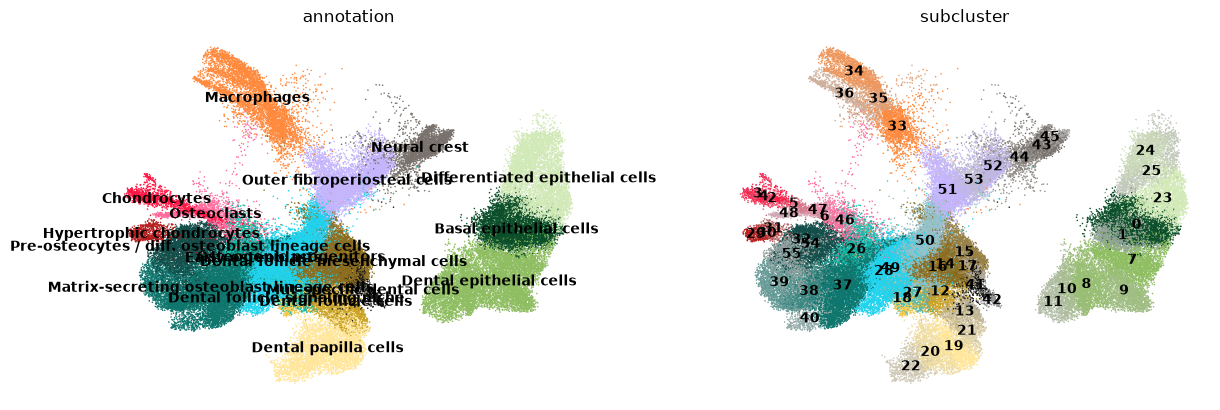

In [33]:
sc.pl.embedding(adata_sub, basis="X_umap", color=["annotation", "subcluster"], size=5, frameon=False, legend_loc="on data")

Parameter
- `ROOT` - DOLEZITE: root vyuzity na orientaciu PAGA grafu a vypocet pseudocasovej osi

In [34]:
ROOT = "49"   # subcluster id from the lookup table above

root_cells = np.flatnonzero(adata_sub.obs["subcluster"] == ROOT)
assert root_cells.size, f"subcluster {ROOT} not found"
print("root:", lookup.loc[lookup["subcluster"] == ROOT, "annotation_sub"].item(), f"({root_cells.size} cells)")

# root cell = tip of the root subcluster: extreme on DC1, on the side facing away from the rest of the data
dc1 = adata_sub.obsm["X_diffmap"][:, 1]
side = np.sign(dc1[root_cells].mean() - dc1.mean()) or 1
adata_sub.uns["iroot"] = root_cells[np.argmax(side * dc1[root_cells])]

sc.tl.dpt(adata_sub, n_dcs=10)
print("cells without finite pseudotime:", (~np.isfinite(adata_sub.obs["dpt_pseudotime"])).sum())

root: Osteogenic progenitors,0 (7088 cells)
cells without finite pseudotime: 0


In [41]:
ADATA = adata_sub
SAMPLE = ["wt_1", "wt_2","wt_3", "wt_4", "mut_1", "mut_2","mut_3", "mut_4"]      # ktore samples zobrazit (aj viac, napr. ["wt_1", "mut_3"])
POINT_SIZE = 30
FIGSIZE = (5, 9)        # per sample 
EMBEDDING = "spatial"   # "X_umap" alebo "spatial"
NCOLS = 4
COLORBAR_loc = "right"  # "right" | "bottom" | None

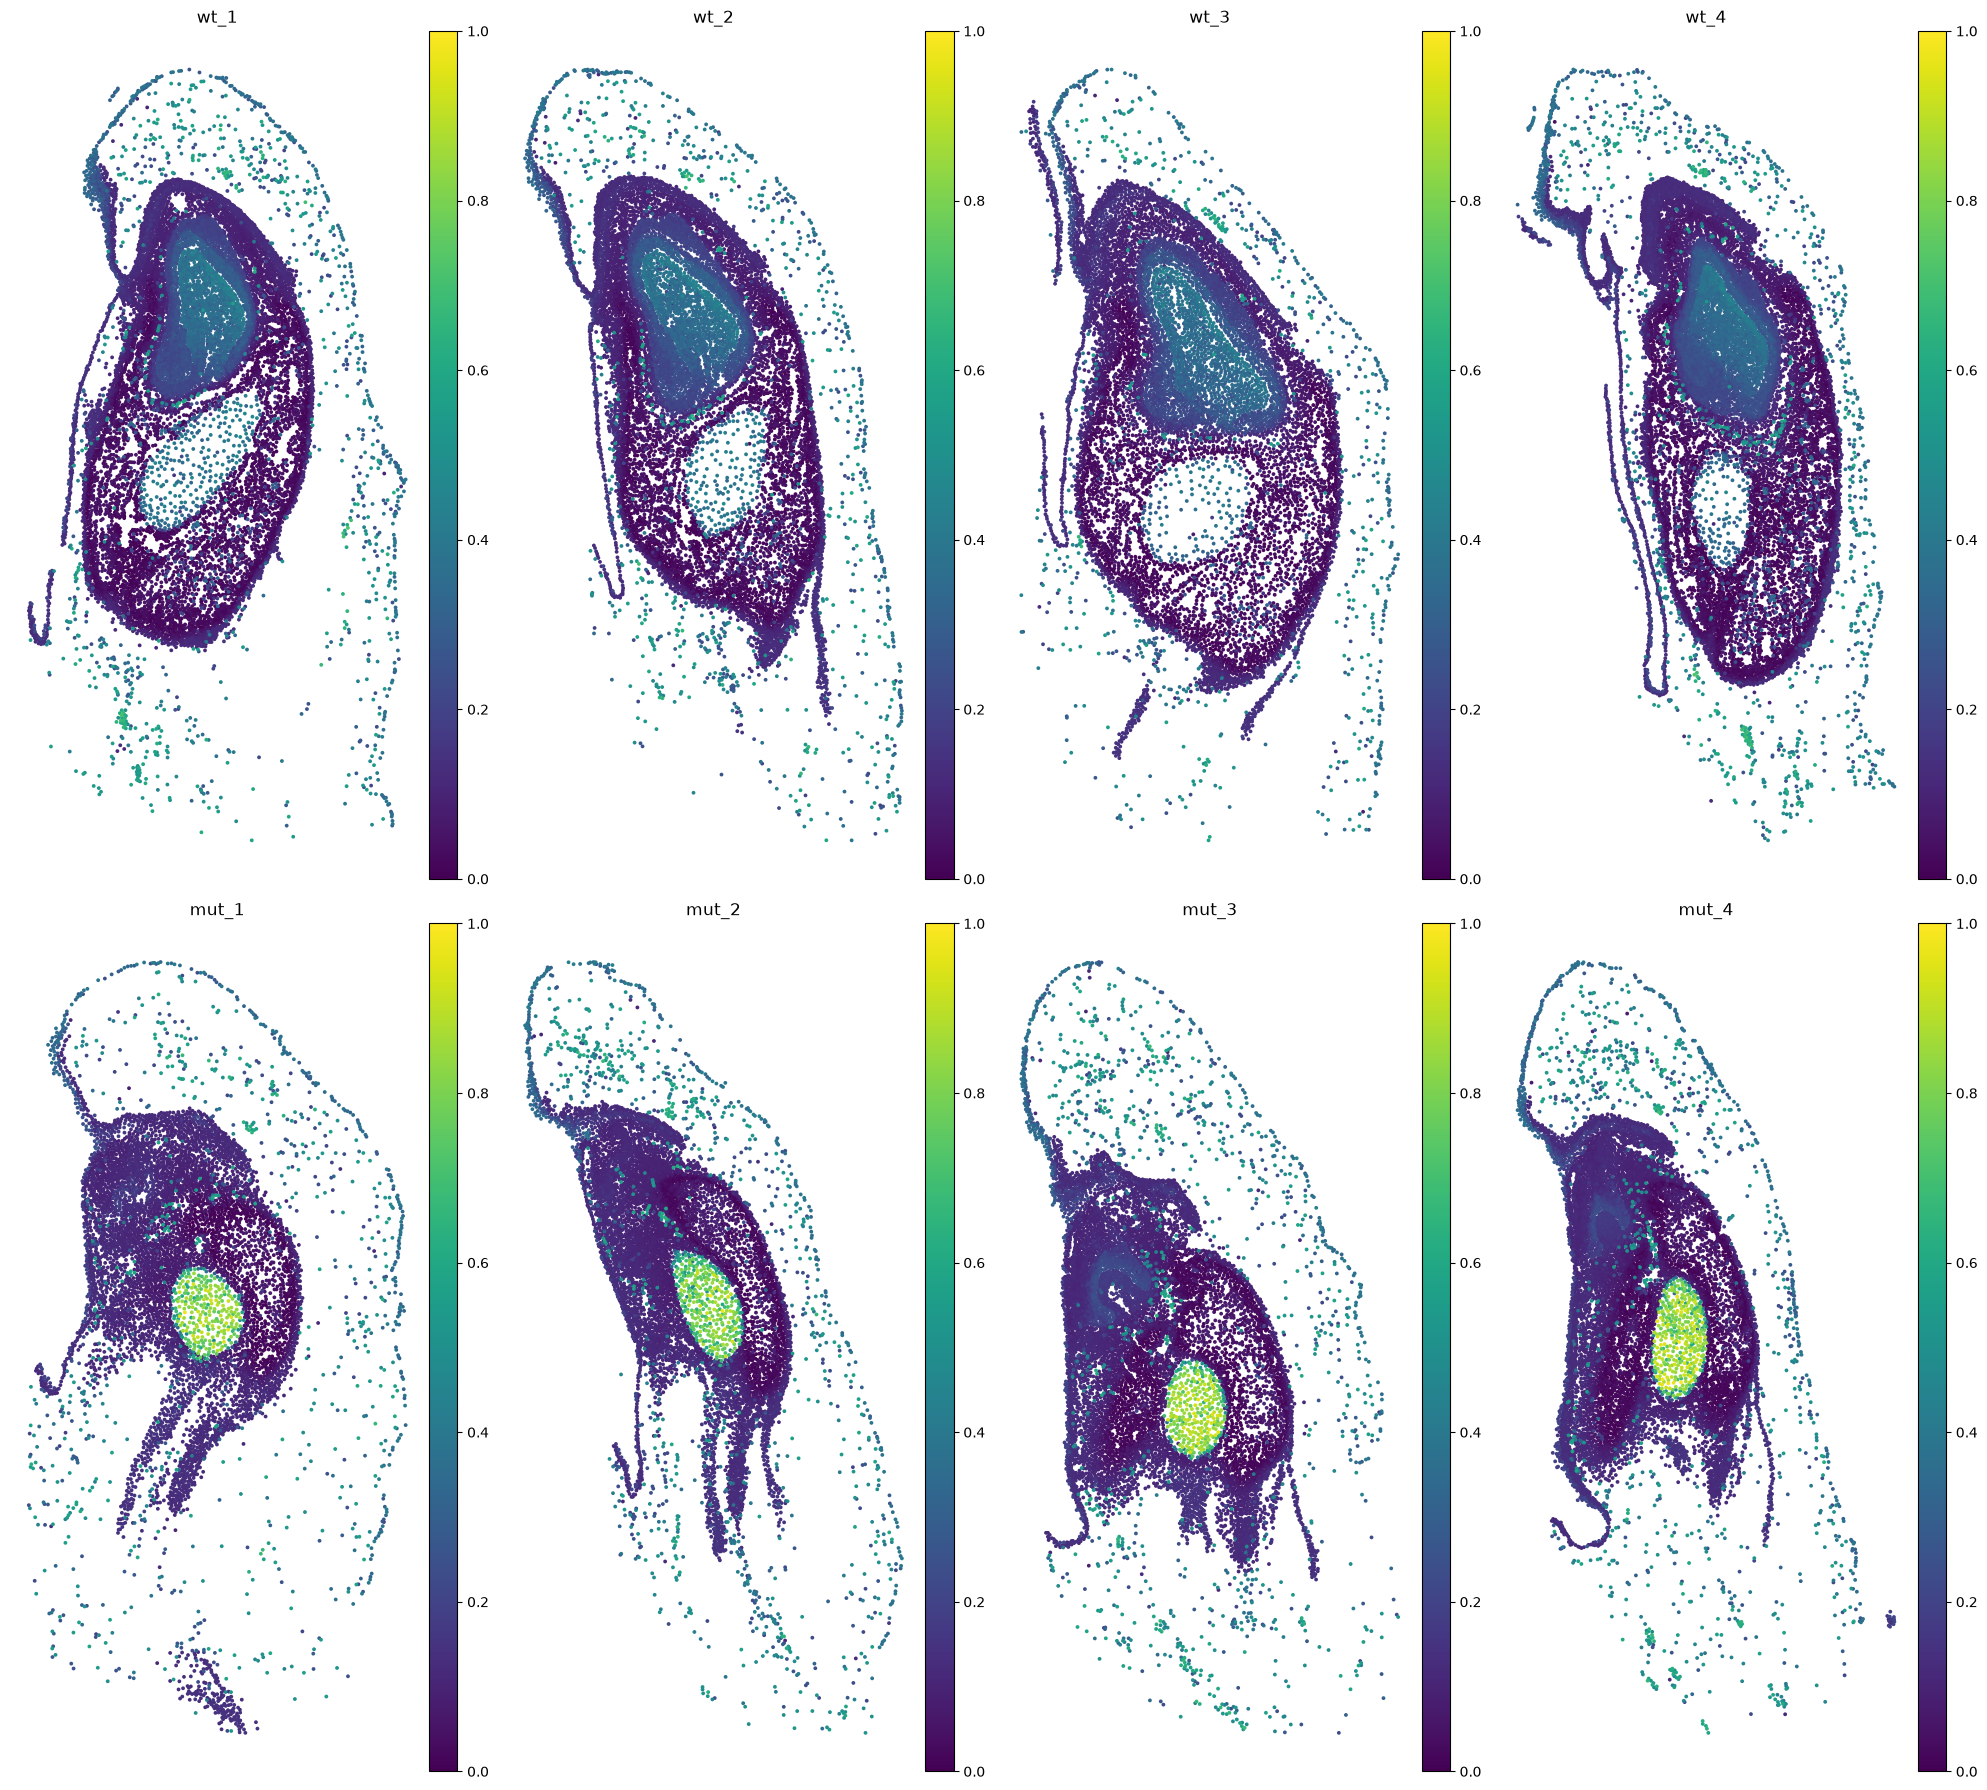

In [42]:
ncols = min(NCOLS, len(SAMPLE))
nrows = int(np.ceil(len(SAMPLE) / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(FIGSIZE[0] * ncols, FIGSIZE[1] * nrows), squeeze=False)
for ax, smp in zip(axs.flat, SAMPLE):
    sub = ADATA[ADATA.obs["sample"] == smp]
    sc.pl.embedding(sub, basis=EMBEDDING, color="dpt_pseudotime", size=POINT_SIZE, na_color="lightgrey",
                    na_in_legend=False, frameon=False, title=smp, ax=ax, show=False, colorbar_loc=COLORBAR_loc, vmin=0, vmax=1)
for ax in axs.flat[len(SAMPLE):]:
    ax.set_axis_off()
plt.tight_layout()
plt.show()

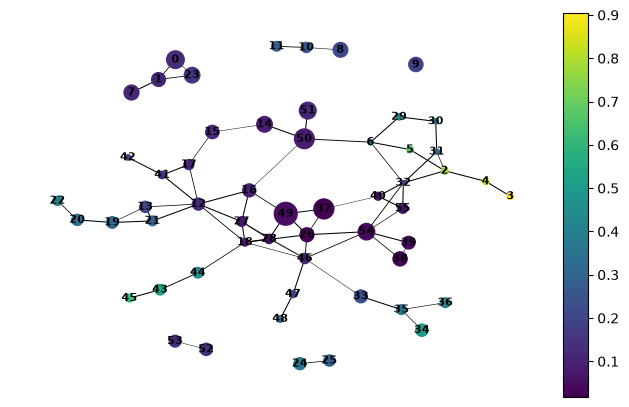

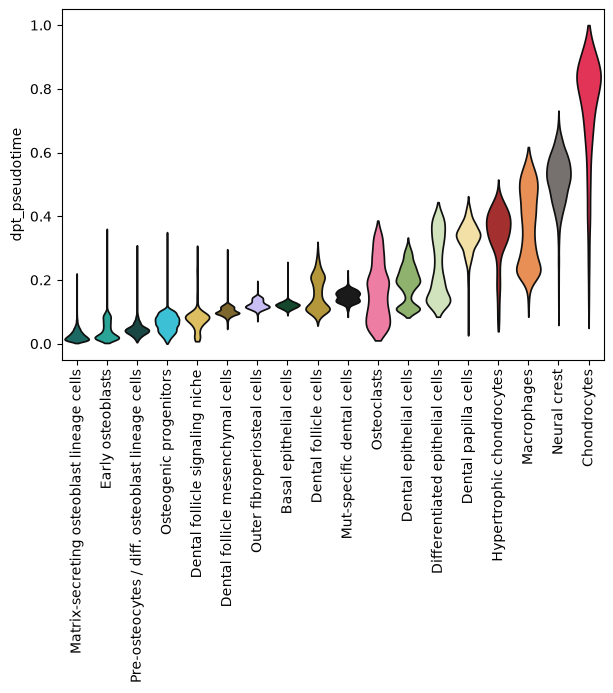

In [43]:
sc.pl.paga(adata_sub, color="dpt_pseudotime", threshold=THRESHOLD, frameon=False,
                edge_width_scale=0.1, node_size_scale=0.5, node_size_power=0.8,
                fontsize=8, cmap="viridis")
order = adata_sub.obs.groupby("annotation", observed=True)["dpt_pseudotime"].median().sort_values().index
sc.pl.violin(adata_sub, "dpt_pseudotime", groupby="annotation", order=list(order),
             rotation=90, stripplot=False)

In [44]:
import os
os.makedirs(d.paga_dir, exist_ok=True)
adata_sub.write_h5ad(d.paga_dir / "adata_sub.h5ad")
print("Wrote", d.paga_dir / "adata_sub.h5ad")

Wrote C:\Users\sevco\Documents\phd\proj_2026_Zimcik_Xenium\Xenium_Analysis_SATB2_UMG_2026\data\04_PAGA\adata_sub.h5ad
